In [1]:
import pandas as pd
import torch
import numpy as np
import torch.nn as nn
import torch.utils.data
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

In [2]:
train_df = pd.read_csv('../data/features/train_features.csv')
test_df = pd.read_csv('../data/features/test_features.csv')
rul_df = pd.read_csv('../data/raw/RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

In [3]:
train_df

,engine_id,cycle,op1,op2,op3,sensor2,sensor3,sensor4,sensor7,sensor9,...,sensor17_mean10,sensor17_std10,sensor20_mean5,sensor20_std5,sensor20_mean10,sensor20_std10,sensor21_mean5,sensor21_std5,sensor21_mean10,sensor21_std10
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.726248,0.109755,...,0.281690,0.000000,0.777542,0.000000,0.765101,0.000000,0.778606,0.000000,0.767143,0.000000
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.628019,0.100242,...,0.281690,0.000000,0.745763,0.130435,0.731544,0.130435,0.782999,0.017365,0.771764,0.017365
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.710145,0.140043,...,0.187793,0.408248,0.717514,0.169323,0.701715,0.169323,0.733906,0.237961,0.720129,0.237961
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.740741,0.124518,...,0.211268,0.353553,0.684852,0.234642,0.667226,0.234642,0.723543,0.202745,0.709230,0.202745
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.668277,0.149960,...,0.253521,0.387298,0.669492,0.226338,0.651007,0.226338,0.728978,0.178837,0.714946,0.178837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,0.477011,0.250000,0.0,0.686747,0.587312,0.782917,0.254428,0.196491,...,0.845070,0.500000,0.086864,0.501133,0.086130,0.476292,0.130353,0.462008,0.111245,0.414727
20627,100,197,0.408046,0.083333,0.0,0.701807,0.729453,0.866475,0.162641,0.194651,...,0.830986,0.512348,0.031780,0.438355,0.044743,0.433137,0.161834,0.499054,0.096900,0.352142
20628,100,198,0.522989,0.500000,0.0,0.665663,0.684979,0.775321,0.175523,0.198196,...,0.873239,0.547723,0.025424,0.421537,0.053691,0.429240,0.127564,0.623208,0.072409,0.435514
20629,100,199,0.436782,0.750000,0.0,0.608434,0.746021,0.747468,0.133655,0.233285,...,0.845070,0.552771,0.006356,0.424554,0.013423,0.368584,0.101433,0.601836,0.073393,0.435090


In [4]:
test_df

,engine_id,cycle,op1,op2,op3,sensor2,sensor3,sensor4,sensor7,sensor9,...,sensor17_mean10,sensor17_std10,sensor20_mean5,sensor20_std5,sensor20_mean10,sensor20_std10,sensor21_mean5,sensor21_std5,sensor21_mean10,sensor21_std10
0,1,1,0.632184,0.750000,0.0,0.545181,0.310661,0.269413,0.652174,0.127614,...,0.281690,0.000000,0.565678,0.000000,0.541387,0.000000,0.691691,0.000000,0.675728,0.000000
1,1,2,0.344828,0.250000,0.0,0.150602,0.379551,0.222316,0.805153,0.146684,...,0.352113,0.250000,0.650424,0.347826,0.630872,0.347826,0.708978,0.068328,0.693910,0.068328
2,1,3,0.517241,0.583333,0.0,0.376506,0.346632,0.322248,0.685990,0.158081,...,0.375587,0.204124,0.699859,0.349633,0.683072,0.349633,0.730659,0.115539,0.716714,0.115539
3,1,4,0.741379,0.500000,0.0,0.370482,0.285154,0.408001,0.679549,0.105717,...,0.316901,0.338502,0.703390,0.286209,0.686801,0.286209,0.721012,0.108660,0.706568,0.108660
4,1,5,0.580460,0.500000,0.0,0.391566,0.352082,0.332039,0.694042,0.102396,...,0.253521,0.460977,0.703390,0.247864,0.686801,0.247864,0.730239,0.110362,0.716272,0.110362
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13091,100,194,0.781609,0.500000,0.0,0.611446,0.619359,0.566172,0.573269,0.541326,...,0.605634,0.335410,0.434322,0.320680,0.418345,0.366354,0.471213,0.350658,0.506540,0.300000
13092,100,195,0.436782,0.416667,0.0,0.605422,0.537388,0.671843,0.542673,0.533743,...,0.619718,0.341565,0.398305,0.392751,0.391499,0.398010,0.441414,0.223156,0.501798,0.299803
13093,100,196,0.465517,0.250000,0.0,0.671687,0.482014,0.414754,0.513688,0.561249,...,0.647887,0.298142,0.341102,0.228416,0.361298,0.366483,0.432703,0.239789,0.478050,0.320116
13094,100,197,0.281609,0.583333,0.0,0.617470,0.522128,0.626435,0.566828,0.570403,...,0.661972,0.291071,0.317797,0.107823,0.337808,0.317123,0.453754,0.238014,0.470134,0.313634


In [5]:
rul_df

,RUL
0,112
1,98
2,69
3,82
4,91
...,...
95,137
96,82
97,59
98,117


### 1. Create sequences (Reshape data into 3D tensors)
  * Understand the 3D input shape PyTorch LSTM expects - (batch_size, sequence_length, features)
  * Choose a sequence length - 30 cycles is the standard starting point for CMAPSS
  * Write a function that takes each engine's flight history and creates sliding windows of 30 consecutive flights
  * For each window, the label (y) is the RUL at the last flight in that window
  * Apply this to both train and validation splits
  * Convert the resulting arrays to PyTorch tensors
  * Confirm your tensors shapes look right before moving on

In [6]:
from sklearn.model_selection import train_test_split
engine_ids = train_df['engine_id'].unique().tolist()
engine_id_train, engine_id_val = train_test_split(engine_ids, test_size=0.2, random_state=1234)

In [7]:
engine_id_train

[10,
 52,
 30,
 89,
 76,
 75,
 63,
 67,
 80,
 49,
 5,
 65,
 11,
 94,
 58,
 73,
 37,
 8,
 55,
 78,
 22,
 19,
 71,
 87,
 23,
 7,
 45,
 9,
 42,
 17,
 46,
 21,
 26,
 56,
 79,
 32,
 93,
 6,
 85,
 33,
 53,
 14,
 92,
 18,
 29,
 47,
 61,
 15,
 66,
 13,
 20,
 3,
 4,
 1,
 12,
 68,
 98,
 35,
 38,
 96,
 51,
 100,
 74,
 81,
 70,
 59,
 91,
 90,
 44,
 31,
 27,
 24,
 50,
 16,
 25,
 77,
 54,
 39,
 84,
 48]

In [8]:
engine_id_val

[41, 36, 82, 62, 99, 69, 86, 28, 40, 43, 34, 60, 64, 95, 57, 88, 97, 2, 72, 83]

In [9]:
train_split = train_df[train_df['engine_id'].isin(engine_id_train)]
val_split = train_df[train_df['engine_id'].isin(engine_id_val)]

In [10]:
train_split.shape, val_split.shape

((16200, 61), (4431, 61))

In [11]:
all_columns = train_split.columns.tolist()
excluded_columns = ['engine_id', 'cycle', 'RUL']
selected_columns = [column for column in all_columns if column not in excluded_columns]

In [12]:
selected_columns

['op1',
 'op2',
 'op3',
 'sensor2',
 'sensor3',
 'sensor4',
 'sensor7',
 'sensor9',
 'sensor11',
 'sensor12',
 'sensor14',
 'sensor17',
 'sensor20',
 'sensor21',
 'sensor2_mean5',
 'sensor2_std5',
 'sensor2_mean10',
 'sensor2_std10',
 'sensor3_mean5',
 'sensor3_std5',
 'sensor3_mean10',
 'sensor3_std10',
 'sensor4_mean5',
 'sensor4_std5',
 'sensor4_mean10',
 'sensor4_std10',
 'sensor7_mean5',
 'sensor7_std5',
 'sensor7_mean10',
 'sensor7_std10',
 'sensor9_mean5',
 'sensor9_std5',
 'sensor9_mean10',
 'sensor9_std10',
 'sensor11_mean5',
 'sensor11_std5',
 'sensor11_mean10',
 'sensor11_std10',
 'sensor12_mean5',
 'sensor12_std5',
 'sensor12_mean10',
 'sensor12_std10',
 'sensor14_mean5',
 'sensor14_std5',
 'sensor14_mean10',
 'sensor14_std10',
 'sensor17_mean5',
 'sensor17_std5',
 'sensor17_mean10',
 'sensor17_std10',
 'sensor20_mean5',
 'sensor20_std5',
 'sensor20_mean10',
 'sensor20_std10',
 'sensor21_mean5',
 'sensor21_std5',
 'sensor21_mean10',
 'sensor21_std10']

In [13]:
def create_sequences(df, sequence_length=50):
    X_list = []
    y_list = []
    
    for engine_id, engine_data in df.groupby('engine_id'):
        engine_data_indexed = engine_data.reset_index()
        for index in range(sequence_length, engine_data_indexed.shape[0] + 1):
            consecutive_flights = engine_data_indexed.iloc[index-sequence_length:index]
            X_list.append(consecutive_flights[selected_columns].values)
            y_list.append(consecutive_flights.iloc[-1]['RUL'])
            
    return np.array(X_list), np.array(y_list)

In [14]:
X_train, y_train = create_sequences(train_split)
X_val, y_val = create_sequences(val_split)

### 2. Build DataLoaders (Batch and shuffle your sequences)
  * Create a PyTorch TensorDataset wrapping your X and y tensors
  * Wrap that in a DataLoader with batch_size=64 and shuffle=True for training
  * Create a separate DataLoader for validation with shuffle=False
  * Confirm the DataLoader produces batches of the right shape

In [15]:
device = "mps" if torch.mps.is_available() else "cpu"

In [16]:
torch.manual_seed(1234)
torch.mps.manual_seed(1234)

In [17]:
X_train_tensor, y_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device), torch.tensor(y_train, dtype=torch.float32).to(device)
X_val_tensor, y_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device), torch.tensor(y_val, dtype=torch.float32).to(device)

In [18]:
trainTensor = TensorDataset(X_train_tensor, y_train_tensor)
valTensor = TensorDataset(X_val_tensor, y_val_tensor)

In [19]:
trainDataLoader = DataLoader(dataset=trainTensor, batch_size=64, shuffle=True)
valDataLoader = DataLoader(dataset=valTensor, batch_size=64, shuffle=False)

In [20]:
X_batch, y_batch = next(iter(trainDataLoader))
print(X_batch.shape)
print(y_batch.shape)

torch.Size([64, 50, 58])
torch.Size([64])


### 3. Define the LSTM model (Build with nn.Module in PyTorch)
  * Create a class that inherits from nn.Module
  * In __init__ define two layers -- an nn.LSTM layer and an nn.Linear output layer
  * LSTM layer takes input_size (number of features = 58), hidden_size (start with 64), num_layers (start with 2), and dropout (0.2)
  * Linear layer maps from hidden_size to 1 (single RUL prediction)
  * In forward, pass input through LSTM, take the last hidden state, pass through Linear layer
  * Move the model to MPS device -- your M5 GPU

In [21]:
class LSTMModel(nn.Module):
  def __init__(self, inputSize=58, hiddenSize=64, numLayers=2, batchFirst=True, dropOut=0.2):
    super().__init__()
    self.lstm_layer = nn.LSTM(inputSize, hiddenSize, numLayers, batch_first=True, dropout=dropOut)
    self.linear_layer = nn.Linear(in_features=hiddenSize, out_features=1)
    
  def forward(self, x):
    output, _ = self.lstm_layer(x)
    return self.linear_layer(output[:, -1, :]).squeeze()

In [22]:
model = LSTMModel().to(device)
print(model)

LSTMModel(
  (lstm_layer): LSTM(58, 64, num_layers=2, batch_first=True, dropout=0.2)
  (linear_layer): Linear(in_features=64, out_features=1, bias=True)
)


### 4. Set up training components
  * Define your loss function -- MSE Loss since this is a regression problem
  * Define your optimizer -- Adam with learning rate 0.001
  * Set your device to MPS for your M5
  * Move your model to that device
  * Define the number of epochs -- start with 50

In [23]:
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
epochs = 110

### 5. Write the training loop (The core of PyTorch training)
  * Loop over the number of epochs
  * For each epoch, loop over batches from your DataLoader
  * Move each batch to your MPS device
  * Forward pass - feed the batch through the model to get predictions
  * Calculate loss - compare predictions to true RUL using MSELoss
  * Zero the gradients
  * Backpropagation - call loss.backward() to calculate gradients
  * Update weights - call optimizer.step() to adjust the model
  * Print training loss every 10 epochs so you can see progress

### 6. Evaluate on validation set (check RMSE during training)
  * After each epoch, run predictions on the validation set
  * Use torch.no_grad() during validation -- no need to calculate gradients
  * Calculate validation RMSE and print alongside training loss
  * Watch for the validation loss diverging from training loss - that's overfitting
  * Plot the training and validation loss curves after training finishes

In [25]:
training_losses = []
validation_losses = []

for epoch in range(epochs):
    # Training
    model.train()
    
    for trainBatch in trainDataLoader:
        optimizer.zero_grad() # clear the gradients
        X_train_batch, y_train_batch = trainBatch
        training_pred = model(X_train_batch)
        training_loss = loss_function(training_pred, y_train_batch)
        training_loss.backward() # backpropagation
        optimizer.step() # gradient descent

    training_losses.append(math.sqrt(training_loss.detach().item()))

    # Validation
    model.eval()
    val_loss_total = 0
    for valBatch in valDataLoader:
        X_val_batch, y_val_batch = valBatch
        with torch.no_grad():
            validation_pred = model(X_val_batch)
            validation_loss = loss_function(validation_pred, y_val_batch)
            val_loss_total += validation_loss.item()
    val_loss_total /= len(valDataLoader)
    
    validation_losses.append(math.sqrt(val_loss_total))
            
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {math.sqrt(training_loss.detach().item()):.4f} | Validation Loss: {math.sqrt(val_loss_total):.4f}")

Epoch: 0 | Loss: 89.7825 | Validation Loss: 85.0671
Epoch: 10 | Loss: 69.8625 | Validation Loss: 74.3393
Epoch: 20 | Loss: 62.6403 | Validation Loss: 65.4229
Epoch: 30 | Loss: 54.8091 | Validation Loss: 57.6318
Epoch: 40 | Loss: 53.3613 | Validation Loss: 51.2003
Epoch: 50 | Loss: 43.5880 | Validation Loss: 46.4724
Epoch: 60 | Loss: 38.4025 | Validation Loss: 43.6591
Epoch: 70 | Loss: 41.3675 | Validation Loss: 42.5144
Epoch: 80 | Loss: 25.4016 | Validation Loss: 29.1467
Epoch: 90 | Loss: 18.9218 | Validation Loss: 22.6485
Epoch: 100 | Loss: 14.0644 | Validation Loss: 17.9550


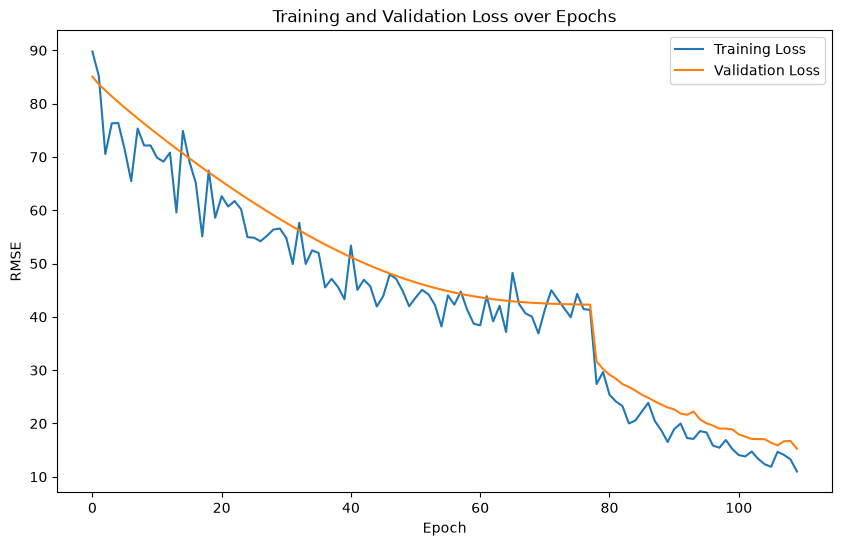

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(training_losses, label='Training Loss')
plt.plot(validation_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.show()

### 7. Optuna hyperparameter tuning



In [27]:
def objective(trial):
    params = {
        "hidden_size": trial.suggest_int('hidden_size', 32, 128),
        "num_layers": trial.suggest_int('num_layers', 2, 3),
        "learning_rate": trial.suggest_float('learning_rate', 0.0001, 0.01),
        "dropout": trial.suggest_float('dropout', 0.1, 0.4),
        "sequence_length": trial.suggest_int('sequence_length', 20, 50)
    }
    
    X_train, y_train = create_sequences(train_split, sequence_length=params["sequence_length"])
    X_val, y_val = create_sequences(val_split, sequence_length=params["sequence_length"])
    
    X_train_tensor, y_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device), torch.tensor(y_train, dtype=torch.float32).to(device)
    X_val_tensor, y_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device), torch.tensor(y_val, dtype=torch.float32).to(device)

    model = LSTMModel(inputSize=58, hiddenSize=params["hidden_size"], numLayers=params["num_layers"], dropOut=params["dropout"]).to(device)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])
    
    trainTensor = TensorDataset(X_train_tensor, y_train_tensor)
    valTensor = TensorDataset(X_val_tensor, y_val_tensor)
    
    trainDataLoader = DataLoader(dataset=trainTensor, batch_size=64, shuffle=True)
    valDataLoader = DataLoader(dataset=valTensor, batch_size=64, shuffle=False)
    
    epochs = 50
    
    for epoch in range(epochs):
        model.train()
        
        for trainBatch in trainDataLoader:
            optimizer.zero_grad() # clear the gradients
            X_train_batch, y_train_batch = trainBatch
            training_pred = model(X_train_batch)
            training_loss = loss_function(training_pred, y_train_batch)
            training_loss.backward() # backpropagation
            optimizer.step() # gradient descent
            
        # Validation
        model.eval()
        val_loss_total = 0
        for valBatch in valDataLoader:
            X_val_batch, y_val_batch = valBatch
            with torch.no_grad():
                validation_pred = model(X_val_batch)
                validation_loss = loss_function(validation_pred, y_val_batch)
                val_loss_total += validation_loss.item()
        val_loss_total /= len(valDataLoader)
            
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Validation Loss: {math.sqrt(val_loss_total):.4f}")
            
    return math.sqrt(val_loss_total)

In [29]:
import optuna

In [30]:
study = optuna.create_study(direction='minimize')

[I 2026-07-12 11:33:51,273] A new study created in memory with name: no-name-aa815157-5c68-4c94-958f-8f5729cdbea1


In [31]:
study.optimize(objective, n_trials=20)

Epoch: 0 | Validation Loss: 42.4411
Epoch: 10 | Validation Loss: 42.2795
Epoch: 20 | Validation Loss: 42.2502
Epoch: 30 | Validation Loss: 42.4068
Epoch: 40 | Validation Loss: 42.3990


[I 2026-07-12 11:34:23,267] Trial 0 finished with value: 42.32340810401534 and parameters: {'hidden_size': 105, 'num_layers': 2, 'learning_rate': 0.00807029900707856, 'dropout': 0.17792732757861904, 'sequence_length': 23}. Best is trial 0 with value: 42.32340810401534.


Epoch: 0 | Validation Loss: 43.0243
Epoch: 10 | Validation Loss: 42.3723
Epoch: 20 | Validation Loss: 42.3337
Epoch: 30 | Validation Loss: 42.2009
Epoch: 40 | Validation Loss: 42.3851


[I 2026-07-12 11:34:57,680] Trial 1 finished with value: 21.4647373385176 and parameters: {'hidden_size': 78, 'num_layers': 2, 'learning_rate': 0.00720523488071669, 'dropout': 0.2508941304539934, 'sequence_length': 41}. Best is trial 1 with value: 21.4647373385176.


Epoch: 0 | Validation Loss: 42.2855
Epoch: 10 | Validation Loss: 42.2092
Epoch: 20 | Validation Loss: 41.9309
Epoch: 30 | Validation Loss: 42.2400
Epoch: 40 | Validation Loss: 41.9927


...

[I 2026-07-12 11:48:18,306] Trial 17 finished with value: 13.15711463118245 and parameters: {'hidden_size': 33, 'num_layers': 3, 'learning_rate': 0.0026931454433925016, 'dropout': 0.27450450017752503, 'sequence_length': 36}. Best is trial 14 with value: 12.636975638822692.


Epoch: 0 | Validation Loss: 48.2889
Epoch: 10 | Validation Loss: 42.7426
Epoch: 20 | Validation Loss: 42.7126
Epoch: 30 | Validation Loss: 19.8553
Epoch: 40 | Validation Loss: 19.4296


[I 2026-07-12 11:49:04,838] Trial 18 finished with value: 14.790901001290022 and parameters: {'hidden_size': 66, 'num_layers': 3, 'learning_rate': 0.005164493728618449, 'dropout': 0.33879999550677614, 'sequence_length': 46}. Best is trial 14 with value: 12.636975638822692.


Epoch: 0 | Validation Loss: 48.6378
Epoch: 10 | Validation Loss: 42.2439
Epoch: 20 | Validation Loss: 42.2689
Epoch: 30 | Validation Loss: 14.1178
Epoch: 40 | Validation Loss: 13.1157


[I 2026-07-12 11:49:50,837] Trial 19 finished with value: 13.210164537996095 and parameters: {'hidden_size': 96, 'num_layers': 3, 'learning_rate': 0.0035128883783087546, 'dropout': 0.3700804166008272, 'sequence_length': 38}. Best is trial 14 with value: 12.636975638822692.


In [32]:
best_parameters = study.best_params
best_parameters

{'hidden_size': 65,
 'num_layers': 3,
 'learning_rate': 0.002523050043858468,
 'dropout': 0.3432028108104811,
 'sequence_length': 45}

In [57]:
import json
with open('../models/lstm_best_params.json', 'w') as f:
    json.dump(best_parameters, f)

In [33]:
best_value = study.best_value
best_value

12.636975638822692

In [34]:
X_train_sequenced, y_train_sequenced = create_sequences(train_split, sequence_length=best_parameters["sequence_length"])
X_val_sequenced, y_val_sequenced = create_sequences(val_split, sequence_length=best_parameters["sequence_length"])

In [35]:
X_train_sequenced_tensors, y_train_sequenced_tensors = torch.tensor(X_train_sequenced, dtype=torch.float32).to(device), torch.tensor(y_train_sequenced, dtype=torch.float32).to(device)
X_val_sequenced_tensors, y_val_sequenced_tensors = torch.tensor(X_val_sequenced, dtype=torch.float32).to(device), torch.tensor(y_val_sequenced, dtype=torch.float32).to(device)

In [36]:
trainSequencedTensor = TensorDataset(X_train_sequenced_tensors, y_train_sequenced_tensors)
valSequencedTensor = TensorDataset(X_val_sequenced_tensors, y_val_sequenced_tensors)

In [37]:
trainSequencedDataLoader = DataLoader(dataset=trainSequencedTensor, batch_size=64, shuffle=True)
valSequencedDataLoader = DataLoader(dataset=valSequencedTensor, batch_size=64, shuffle=False)

In [38]:
best_model = LSTMModel(inputSize=58, hiddenSize=best_parameters["hidden_size"], numLayers=best_parameters["num_layers"], dropOut=best_parameters["dropout"]).to(device)

In [39]:
new_loss_function = nn.MSELoss()
new_optimizer = torch.optim.Adam(best_model.parameters(), lr=best_parameters["learning_rate"])
epochs = 110

In [40]:
training_losses = []
validation_losses = []

for epoch in range(epochs):
    # Training
    best_model.train()
    
    for trainBatch in trainSequencedDataLoader:
        new_optimizer.zero_grad() # clear the gradients
        X_train_batch, y_train_batch = trainBatch
        training_pred = best_model(X_train_batch)
        training_loss = new_loss_function(training_pred, y_train_batch)
        training_loss.backward() # backpropagation
        new_optimizer.step() # gradient descent

    training_losses.append(math.sqrt(training_loss.detach().item()))

    # Validation
    best_model.eval()
    val_loss_total = 0
    for valBatch in valSequencedDataLoader:
        X_val_batch, y_val_batch = valBatch
        with torch.no_grad():
            validation_pred = best_model(X_val_batch)
            validation_loss = new_loss_function(validation_pred, y_val_batch)
            val_loss_total += validation_loss.item()
    val_loss_total /= len(valSequencedDataLoader)
    
    validation_losses.append(math.sqrt(val_loss_total))
            
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {math.sqrt(training_loss.detach().item()):.4f} | Validation Loss: {math.sqrt(val_loss_total):.4f}")

Epoch: 0 | Loss: 69.4205 | Validation Loss: 62.0282
Epoch: 10 | Loss: 43.8688 | Validation Loss: 42.4904
Epoch: 20 | Loss: 46.8076 | Validation Loss: 42.4804
Epoch: 30 | Loss: 44.3446 | Validation Loss: 42.4021
Epoch: 40 | Loss: 11.6221 | Validation Loss: 12.5168
Epoch: 50 | Loss: 17.3655 | Validation Loss: 12.2671
Epoch: 60 | Loss: 8.6076 | Validation Loss: 12.2353
Epoch: 70 | Loss: 6.2642 | Validation Loss: 12.9010
Epoch: 80 | Loss: 15.0422 | Validation Loss: 14.1446
Epoch: 90 | Loss: 6.3105 | Validation Loss: 13.7593
Epoch: 100 | Loss: 7.1603 | Validation Loss: 14.5887


### 7. Evaluate on test set (Get your official LSTM RMSE)
  * Create sequences from testing_data the same way you did for training
  * Get the last sequence for each test engine
  * Run predictions with torch.no_grad()
  * Compare against answer_key to get official test RMSE
  * Compare against your XGBoost test RMSE of 19.70

In [47]:
test_df.groupby('engine_id')['cycle'].count().sort_values().max()

np.int64(303)

In [52]:
X_test = []

for engine_id, engine_data in test_df.groupby('engine_id'):
    last_n_flights = engine_data.tail(best_parameters['sequence_length'])
    
    if len(last_n_flights) < best_parameters['sequence_length']:
        missing_num_of_rows = best_parameters['sequence_length'] - len(last_n_flights)
        zero_matrix = np.zeros((missing_num_of_rows, 58), dtype=np.float32)
        real_flights = last_n_flights[selected_columns].values
        X_test.append(np.vstack([zero_matrix, real_flights]))
    else:
        X_test.append(last_n_flights[selected_columns].values)
        

X_test = np.array(X_test)

In [53]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

In [54]:
best_model.eval()
with torch.no_grad():
    y_test_pred = best_model(X_test_tensor)

y_test_pred = y_test_pred.cpu().numpy()
test_rmse = root_mean_squared_error(rul_df['RUL'], y_test_pred)

In [55]:
test_rmse

18.108158111572266

### 8. Save best_model to models/lstm_model.pt

In [56]:
torch.save(best_model.state_dict(), '../models/lstm_model.pt')